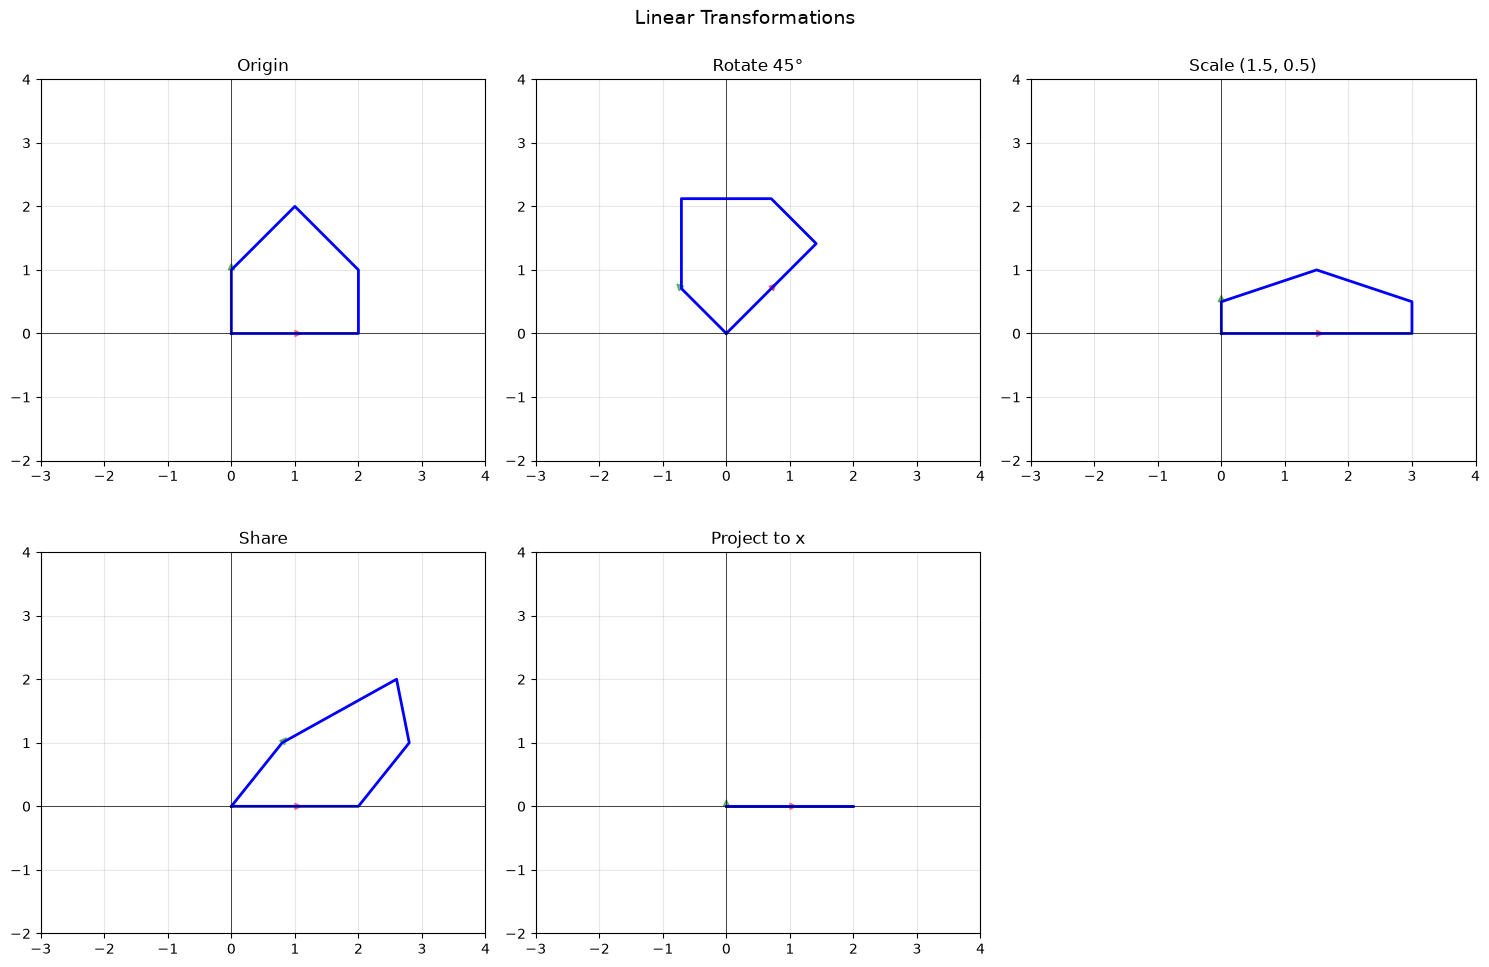

变换的组合


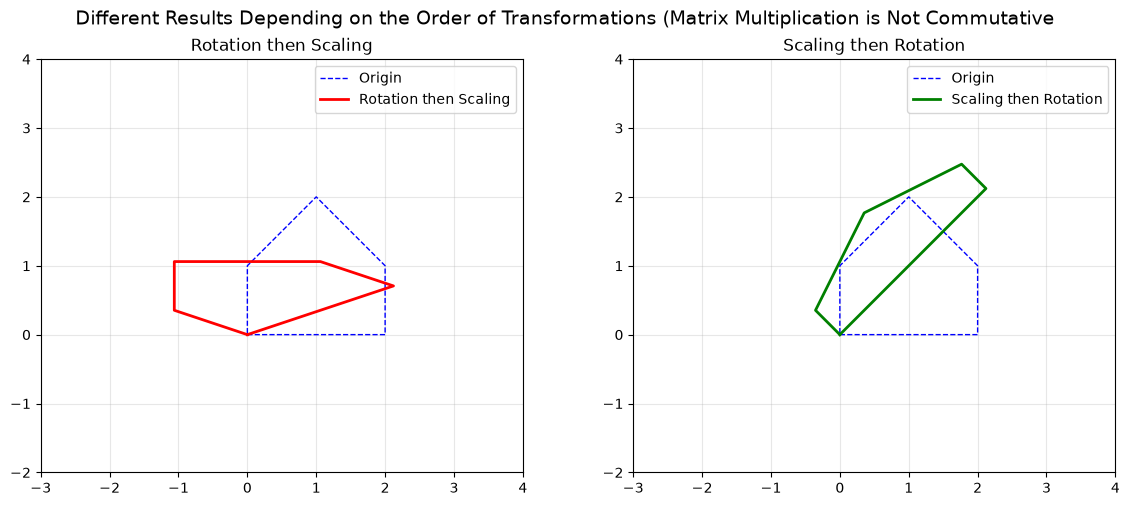

S @ R 和 R @ S 是否相等？ False
矩阵乘法不交换，所以变换顺序很重要！


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 定义一个测试形状（房子） ----
def create_house():
    """返回一个房子的顶点坐标"""
    return np.array([
        [0, 0],    # 左下
        [2, 0],    # 右下
        [2, 1],    # 右下屋顶
        [1, 2],    # 屋顶尖
        [0, 1],    # 左上屋顶
        [0, 0],    # 回到起点
    ])

house = create_house()

# ---- 定义各种变换矩阵 ----
theta = np.pi / 4  # 45度
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])  # 旋转45度

S = np.array([[1.5, 0],
              [0, 0.5]])  # x轴拉伸1.5倍，y轴压缩0.5倍

H = np.array([[1, 0.8],
              [0, 1]])  # 剪切

P = np.array([[1, 0],
              [0, 0]])  # 投影到x轴

# ---- 应用变换 ----
transforms = [
    ("Origin", np.eye(2)),
    ("Rotate 45°", R),
    ("Scale (1.5, 0.5)", S),
    ("Share", H),
    ("Project to x", P)
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, A) in enumerate(transforms):
    transformed = house @ A.T
    ax = axes[idx]
    ax.plot(transformed[:, 0], transformed[:, 1], 'b-', linewidth=2)
    # 画坐标轴
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    # 画变换后的单位向量
    e1 = A @ np.array([1, 0])
    e2 = A @ np.array([0, 1])
    ax.arrow(0, 0, e1[0], e1[1], head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.5)
    ax.arrow(0, 0, e2[0], e2[1], head_width=0.1, head_length=0.1, fc='green', ec='green', alpha=0.5)
    
    ax.set_xlim(-3, 4)
    ax.set_ylim(-2, 4)
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

# 隐藏第6个子图（如果有）
if len(transforms) < 6:
    axes[-1].set_visible(False)

plt.suptitle('Linear Transformations', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 变换的组合 ----
print("=" * 60)
print("变换的组合")
print("=" * 60)

# 先旋转再缩放 (S @ R)
SR = S @ R
house_SR = house @ SR.T

# 先缩放再旋转 (R @ S)
RS = R @ S
house_RS = house @ RS.T

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(house[:, 0], house[:, 1], 'b--', linewidth=1, label='Origin')
plt.plot(house_SR[:, 0], house_SR[:, 1], 'r-', linewidth=2, label='Rotation then Scaling')
plt.xlim(-3, 4)
plt.ylim(-2, 4)
plt.title('Rotation then Scaling')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal')

plt.subplot(1, 2, 2)
plt.plot(house[:, 0], house[:, 1], 'b--', linewidth=1, label='Origin')
plt.plot(house_RS[:, 0], house_RS[:, 1], 'g-', linewidth=2, label='Scaling then Rotation')
plt.xlim(-3, 4)
plt.ylim(-2, 4)
plt.title('Scaling then Rotation')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal')

# plt.suptitle('变换顺序不同，结果不同 (矩阵乘法不交换)', fontsize=14)
plt.suptitle('Different Results Depending on the Order of Transformations (Matrix Multiplication is Not Commutative', fontsize=14)
plt.tight_layout()
plt.show()

print(f"S @ R 和 R @ S 是否相等？ {np.allclose(SR, RS)}")
print("矩阵乘法不交换，所以变换顺序很重要！")